In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve

In [28]:
df = pd.read_csv('../data/cleaned_employee_attrition.csv')
df.head(10)

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,IncomeBin
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,3,...,1,0,8,3,1,6,4,0,5,3k-6k
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,3,Male,2,...,4,1,10,3,3,10,7,1,7,3k-6k
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,4,Male,2,...,2,0,7,3,3,0,0,0,0,0-3k
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,4,Female,3,...,3,0,8,3,3,8,7,3,0,0-3k
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,Male,3,...,4,1,6,3,3,2,2,2,2,3k-6k
5,32,No,Travel_Frequently,Research & Development,2,2,Life Sciences,4,Male,3,...,3,0,8,2,2,7,7,3,6,3k-6k
6,59,No,Travel_Rarely,Research & Development,3,3,Medical,3,Female,4,...,1,1,12,3,2,1,0,0,0,0-3k
7,30,No,Travel_Rarely,Research & Development,24,1,Life Sciences,4,Male,3,...,2,1,1,2,3,1,0,0,0,0-3k
8,38,No,Travel_Frequently,Research & Development,23,3,Life Sciences,4,Male,2,...,2,0,10,2,3,9,7,1,8,9k-12k
9,36,No,Travel_Rarely,Research & Development,27,3,Medical,3,Male,3,...,2,2,17,3,2,7,7,7,7,3k-6k


In [29]:
df['IncomeBin'].describe()

count      1470
unique        6
top       3k-6k
freq        633
Name: IncomeBin, dtype: object

In [30]:
X = df.drop('Attrition', axis=1)
y = df['Attrition'].map({'No': 0, 'Yes': 1})

In [31]:
X.shape, y.shape

((1470, 28), (1470,))

In [32]:
# Select categorical features
categorical_features = X.select_dtypes(include='object').columns
categorical_features

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime', 'IncomeBin'],
      dtype='object')

In [33]:

X = pd.get_dummies(X, columns=categorical_features, drop_first=True, dtype=int)  # Convert categorical variables to dummy/indicator variables
len(X.columns)

46

In [34]:
X.columns

Index(['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Male',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research Director', 'JobRole_Research Scientist',
       'JobRole_Sales Executive', 'JobRole_S

In [35]:
rf = RandomForestClassifier(
    n_estimators=300,          # more trees → smoother importance estimates
    max_depth=8,               # limit depth to avoid overfitting
    min_samples_split=10,      # require more samples to split → generalization
    min_samples_leaf=5,        # avoid tiny leaves
    max_features='sqrt',       # common choice for classification
    class_weight='balanced',   # handle attrition imbalance
    random_state=42
)

rf.fit(X, y)



# Feature importance
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

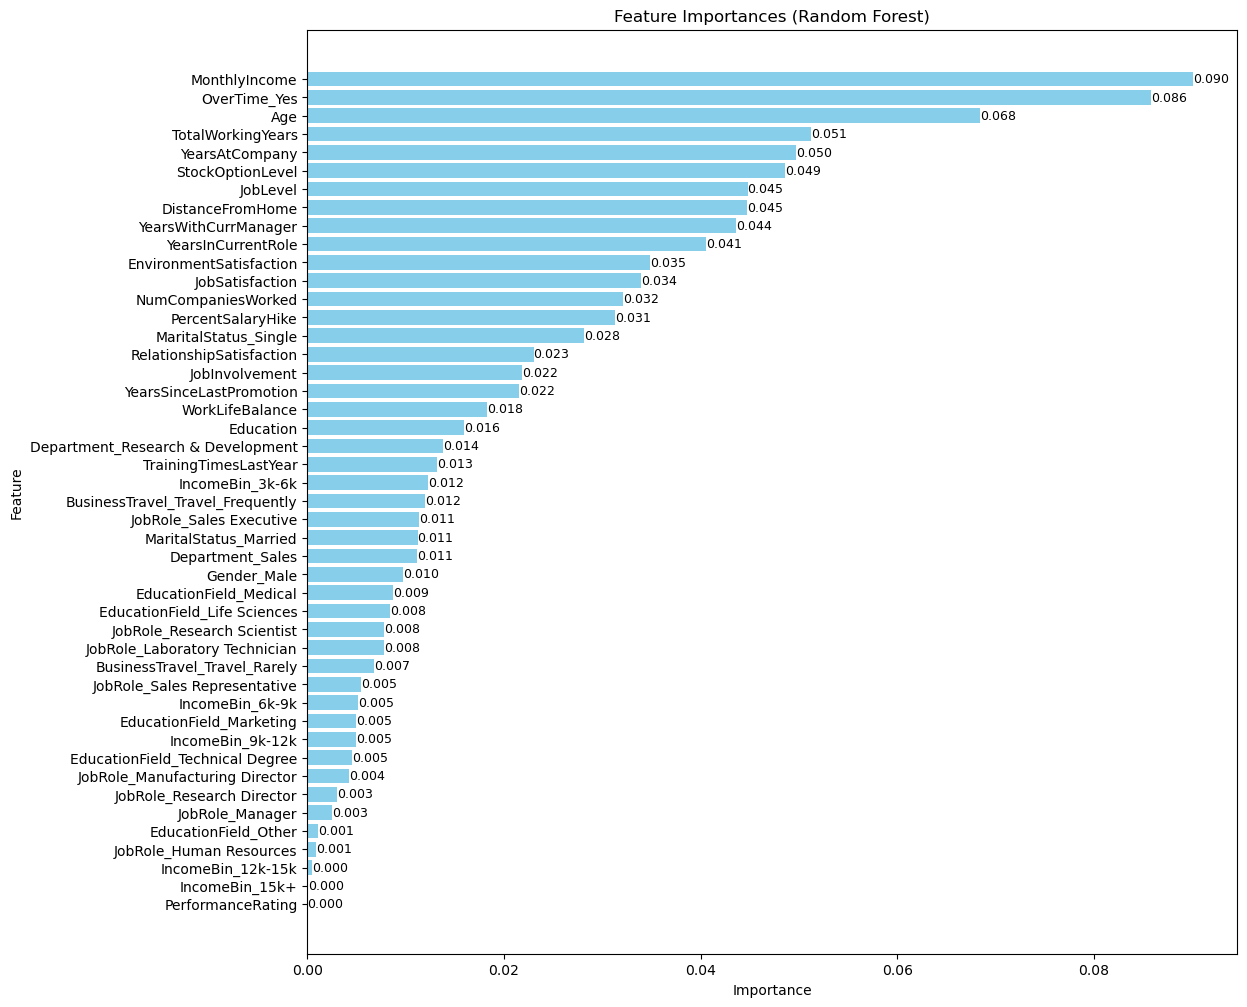

In [36]:
# Plot
plt.figure(figsize=(12,12))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='skyblue')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importances (Random Forest)")
plt.gca().invert_yaxis()  # highest importance at the top

# Annotate each bar with its importance value
for index, value in enumerate(feature_importances['Importance']):
    plt.text(value, index, f"{value:.3f}", va='center', ha='left', fontsize=9, color='black')

plt.show()

In [37]:
# Drop features with very low importance
low_importance = feature_importances[feature_importances['Importance'] < 0.02]['Feature'].tolist()
X = X.drop(low_importance, axis=1)
X.columns # only important features left
X.head()

,Age,DistanceFromHome,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,MaritalStatus_Single,OverTime_Yes
0,41,1,2,3,2,4,5993,8,11,1,0,8,6,4,0,5,1,1
1,49,8,3,2,2,2,5130,1,23,4,1,10,10,7,1,7,0,0
2,37,2,4,2,1,3,2090,6,15,2,0,7,0,0,0,0,1,1
3,33,3,4,3,1,3,2909,1,11,3,0,8,8,7,3,0,0,1
4,27,2,1,3,1,2,3468,2,12,4,1,6,2,2,2,2,0,0


In [38]:
X.to_csv('../data/training_dataset.csv')

In [39]:
X_train, X_test,  y_train, y_test = train_test_split(X, y, random_state= 42, test_size=0.2, stratify=y)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)


(1176, 18) (1176,) (294, 18) (294,)


In [40]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

joblib.dump(scaler, '../models/scaler.pkl')
print(X_train.shape, X_test.shape)

(1176, 18) (294, 18)


In [41]:
print(y_train.value_counts())
print(y_test.value_counts())

Attrition
0    986
1    190
Name: count, dtype: int64
Attrition
0    247
1     47
Name: count, dtype: int64


In [42]:
# Calculating weights of each clases

w0 =  (X_train.shape[0]) / (2 * y_train.value_counts()[0]) # weight of class No(0)
w1 =  (X_train.shape[0]) / (2 * y_train.value_counts()[1]) # weight of class Yes(1)

In [43]:
print("Weight of class No : ", w0)
print("Weight of class Yes :", w1)

Weight of class No :  0.5963488843813387
Weight of class Yes : 3.094736842105263


In [44]:
def evaluate(model, X, y_true, labels: str, name: str = None):
    y_pred = model.predict(X)
    
    # Metrics
    results = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_pred)
    }
    
    # Convert to DataFrame for pretty display
    results_df = pd.DataFrame(results, index=["Score"]).T
    
    print("\n📊 Model Evaluation Results\n")
    print(results_df.round(5))  # rounded to 3 decimals
    
    if labels == 'Testing':
        # Confusion Matrix Heatmap
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", cbar=False,
                xticklabels=['Positive', 'Negative'],
                yticklabels=['True', 'False'])
        plt.title(f"Confusion Matrix Heatmap")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()
        joblib.dump(model, f'../models/{name}_model.pkl')
            

### Logistics Regression CV

In [45]:
# Base model
log_reg = LogisticRegression(penalty='l2', solver='lbfgs', class_weight={0 : w0, 1: w1}, max_iter=1000, random_state=42)

# Fit model
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight={0: np.float64(0.5963488843813387),
                                 1: np.float64(3.094736842105263)},
                   max_iter=1000, random_state=42)

In [46]:
print('='* 50)
print('Training Prediction')
print('='* 50)
evaluate(log_reg, X_train, y_train, 'Training')


Training Prediction

📊 Model Evaluation Results

             Score
Accuracy   0.74830
Precision  0.36683
Recall     0.76842
F1-Score   0.49660
ROC-AUC    0.75642


Testing Prediction

📊 Model Evaluation Results

             Score
Accuracy   0.73469
Precision  0.34951
Recall     0.76596
F1-Score   0.48000
ROC-AUC    0.74735


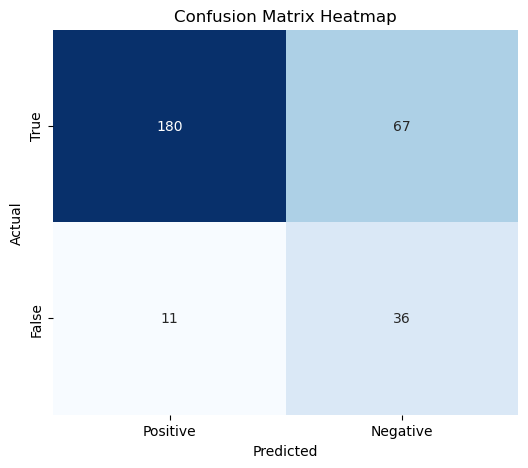

In [47]:
print('='* 50)
print('Testing Prediction')
print('='* 50)
evaluate(log_reg, X_test, y_test, 'Testing', 'logistic_regression')

## Random Forest

In [48]:
rf = RandomForestClassifier(
    criterion='entropy',
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=18,
    max_features='sqrt',
    class_weight={0: w0, 1: w1},   # your chosen weighting
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: np.float64(0.5963488843813387),
                                     1: np.float64(3.094736842105263)},
                       criterion='entropy', max_depth=5, min_samples_leaf=18,
                       min_samples_split=10, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [49]:
print('='* 50)
print('Training Prediction')
print('='* 50)
evaluate(rf , X_train, y_train, 'Training')



Training Prediction

📊 Model Evaluation Results

             Score
Accuracy   0.86395
Precision  0.56303
Recall     0.70526
F1-Score   0.62617
ROC-AUC    0.79989


Testing Prediction

📊 Model Evaluation Results

             Score
Accuracy   0.80612
Precision  0.42188
Recall     0.57447
F1-Score   0.48649
ROC-AUC    0.71234


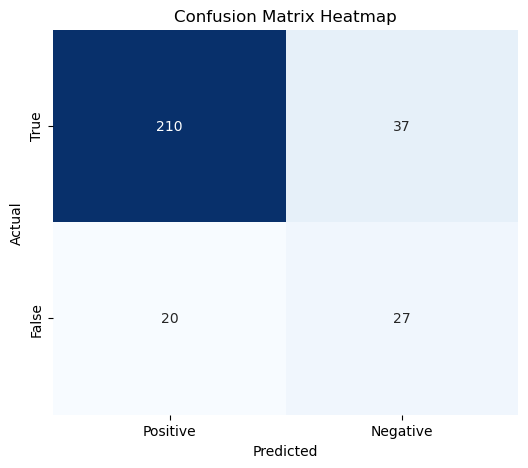

In [50]:
print('='* 50)
print('Testing Prediction')
print('='* 50)
evaluate(rf , X_test, y_test, 'Testing', 'random_forest')

## XGBoost Algorithm

In [51]:
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=ratio,
    random_state=42
)

In [52]:
param_grid = {
    'max_depth': [3, 4],
    'min_child_weight': [5, 8],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'gamma': [1, 2],
    'reg_alpha': [0.1, 1],
    'reg_lambda': [1, 5]
}

In [53]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best AUC:", grid.best_score_)
print("Best Params:")
print(grid.best_params_)

Fitting 5 folds for each of 128 candidates, totalling 640 fits
Best AUC: 0.8003881993863292
Best Params:
{'colsample_bytree': 0.8, 'gamma': 2, 'max_depth': 4, 'min_child_weight': 8, 'reg_alpha': 1, 'reg_lambda': 5, 'subsample': 0.8}


In [54]:
best_xgb = grid.best_estimator_

In [55]:
print('='* 50)
print('Training Prediction')
print('='* 50)
evaluate(best_xgb , X_train, y_train, 'Training')

Training Prediction

📊 Model Evaluation Results

             Score
Accuracy   0.93452
Precision  0.72332
Recall     0.96316
F1-Score   0.82619
ROC-AUC    0.94608


Testing Prediction

📊 Model Evaluation Results

             Score
Accuracy   0.80612
Precision  0.41935
Recall     0.55319
F1-Score   0.47706
ROC-AUC    0.70372


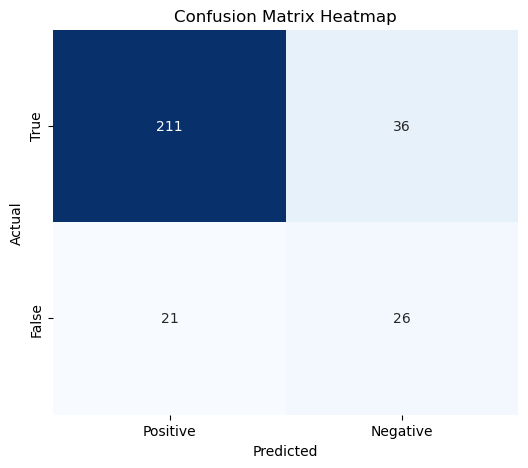

In [56]:
print('='* 50)
print('Testing Prediction')
print('='* 50)
evaluate(best_xgb , X_test, y_test, 'Testing', 'xgb')


## Comparision using ROC Curve models

In [57]:
def plot_roc_curves(models, X_test, y_test, labels):
    plt.figure(figsize=(8,6))
    
    for model, label in zip(models, labels):
        # Get predicted probabilities for the positive class
        y_pred = model.predict(X_test)
        
        # Compute ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred)
        
        # Plot ROC curve
        plt.plot(fpr, tpr, label=f"{label} (AUC = {auc:.3f})")
    
    # Plot baseline
    plt.plot([0,1], [0,1], 'k--', label="Random Guess")
    
    plt.title("ROC Curves - Logistic Regression vs Random Forest vs XGBoost")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

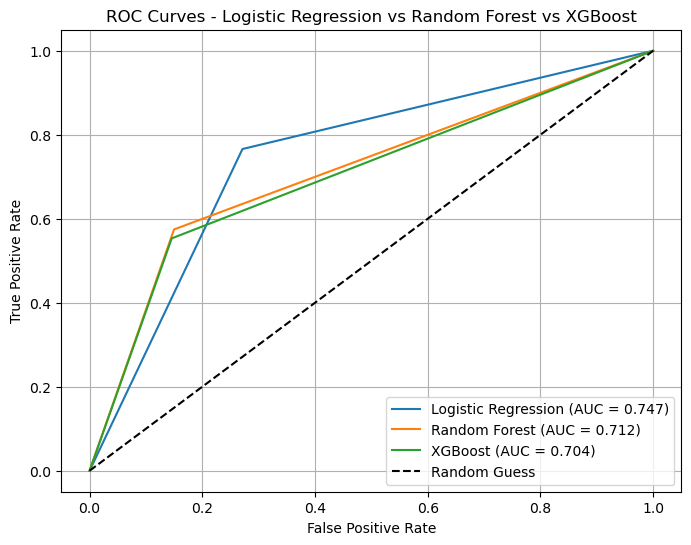

In [58]:
models = [log_reg, rf, best_xgb]
labels = ["Logistic Regression", "Random Forest", "XGBoost"]

plot_roc_curves(models, X_test, y_test, labels)